<a href="https://colab.research.google.com/github/ayushgkp/UCS547-Accelerated-Data-Science/blob/main/Assignment5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install opencv-python-headless matplotlib -q
!pip install cupy-cuda12x -q          # adjust cuda version if needed

# Download 15 sample images for Q1 & Q2
import os, urllib.request
os.makedirs("images", exist_ok=True)

# Using Lorem Picsum for sample JPEGs
for i in range(1, 21):
    url = f"https://picsum.photos/seed/{i}/800/600"
    urllib.request.urlretrieve(url, f"images/img_{i:02d}.jpg")

print(f"Downloaded {len(os.listdir('images'))} images")

Downloaded 20 images


Q1 — CPU Pipeline vs GPU Pipeline + Table + Graph

Running pipelines...

── Per-Image Results ──────────────────────────────────
+------------+------------+------------+-----------+
| Image      |   CPU (ms) |   GPU (ms) |   Speedup |
+============+============+============+===========+
| img_01.jpg |     131.02 |    2702.13 |      0.05 |
+------------+------------+------------+-----------+
| img_02.jpg |       4.71 |      15.85 |      0.3  |
+------------+------------+------------+-----------+
| img_03.jpg |       8.21 |      19.31 |      0.43 |
+------------+------------+------------+-----------+
| img_04.jpg |       7.61 |      18.67 |      0.41 |
+------------+------------+------------+-----------+
| img_05.jpg |       4.31 |      15.56 |      0.28 |
+------------+------------+------------+-----------+
| img_06.jpg |       5.87 |      18.41 |      0.32 |
+------------+------------+------------+-----------+
| img_07.jpg |       5.11 |      16.04 |      0.32 |
+------------+------------+------------+-----------+
| img_08.jpg |       

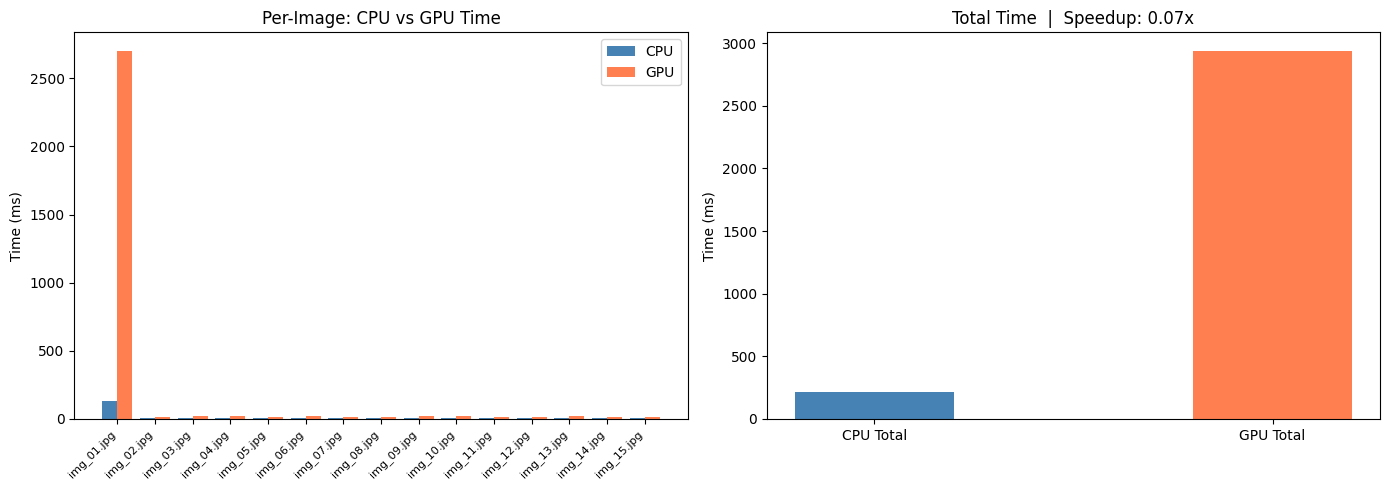

In [2]:
import cv2
import numpy as np
import cupy as cp
import time
import os
import matplotlib.pyplot as plt
from tabulate import tabulate

image_dir = "images"
image_files = sorted([os.path.join(image_dir, f)
                      for f in os.listdir(image_dir) if f.endswith(".jpg")])[:15]

TARGET = (512, 512)

# ─── CPU Pipeline ───────────────────────────────────────────
def cpu_pipeline(path):
    t = time.perf_counter()
    img = cv2.imread(path)                        # load JPEG
    img = cv2.resize(img, TARGET)                 # resize 512x512
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # grayscale
    return time.perf_counter() - t

# ─── GPU Pipeline (CuPy simulating GPU ops) ─────────────────
def gpu_pipeline(path):
    t = time.perf_counter()
    img = cv2.imread(path)                        # decode on CPU (nvJPEG substitute)
    img_gpu = cp.asarray(img)                     # transfer to GPU
    # resize on GPU using cupy zoom
    zoom_y = TARGET[0] / img_gpu.shape[0]
    zoom_x = TARGET[1] / img_gpu.shape[1]
    import cupyx.scipy.ndimage as cpnd
    img_gpu = cpnd.zoom(img_gpu, (zoom_y, zoom_x, 1))
    # grayscale: 0.114B + 0.587G + 0.299R (BGR order)
    gray_gpu = (0.114 * img_gpu[:,:,0] +
                0.587 * img_gpu[:,:,1] +
                0.299 * img_gpu[:,:,2]).astype(cp.uint8)
    cp.cuda.Stream.null.synchronize()
    return time.perf_counter() - t

# ─── Benchmark ──────────────────────────────────────────────
cpu_times, gpu_times = [], []
rows = []

print("Running pipelines...")
for path in image_files:
    name = os.path.basename(path)
    ct = cpu_pipeline(path)
    gt = gpu_pipeline(path)
    cpu_times.append(ct)
    gpu_times.append(gt)
    rows.append([name, f"{ct*1000:.2f}", f"{gt*1000:.2f}", f"{ct/gt:.2f}"])

# Summary
total_cpu = sum(cpu_times)
total_gpu = sum(gpu_times)
avg_cpu   = total_cpu / len(cpu_times)
avg_gpu   = total_gpu / len(gpu_times)
speedup   = total_cpu / total_gpu

print("\n── Per-Image Results ──────────────────────────────────")
print(tabulate(rows,
      headers=["Image", "CPU (ms)", "GPU (ms)", "Speedup"],
      tablefmt="grid"))

print(f"\n── Summary ────────────────────────────────────────────")
print(f"Total CPU time  : {total_cpu*1000:.2f} ms")
print(f"Total GPU time  : {total_gpu*1000:.2f} ms")
print(f"Avg CPU/image   : {avg_cpu*1000:.2f} ms")
print(f"Avg GPU/image   : {avg_gpu*1000:.2f} ms")
print(f"Overall Speedup : {speedup:.2f}x")

# ─── Graph ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = [os.path.basename(p) for p in image_files]
x = np.arange(len(labels))

axes[0].bar(x - 0.2, [t*1000 for t in cpu_times], 0.4, label='CPU', color='steelblue')
axes[0].bar(x + 0.2, [t*1000 for t in gpu_times], 0.4, label='GPU', color='coral')
axes[0].set_xticks(x); axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel("Time (ms)"); axes[0].set_title("Per-Image: CPU vs GPU Time")
axes[0].legend()

axes[1].bar(["CPU Total", "GPU Total"],
            [total_cpu*1000, total_gpu*1000],
            color=['steelblue', 'coral'], width=0.4)
axes[1].set_ylabel("Time (ms)"); axes[1].set_title(f"Total Time  |  Speedup: {speedup:.2f}x")

plt.tight_layout()
plt.savefig("q1_comparison.png", dpi=150)
plt.show()

GPU-based decoding with nvJPEG is faster because JPEG decoding involves heavy parallel steps — Huffman decoding, IDCT, color conversion — which map well to GPU's thousands of cores. For large batches, the GPU keeps its pipeline full. However, the advantage reduces when: (1) images are very small (GPU overhead dominates), (2) batch size is 1 (no parallelism benefit), (3) PCIe transfer time is high (bottleneck shifts to CPU↔GPU data movement), or (4) the GPU is already busy with other tasks.

Q2 — Grayscale: Direct vs Manual from RGB, Two Resolutions


=== Resolution: 800x600 ===
Max pixel diff between methods : 1
Mean pixel diff                : 0.0180


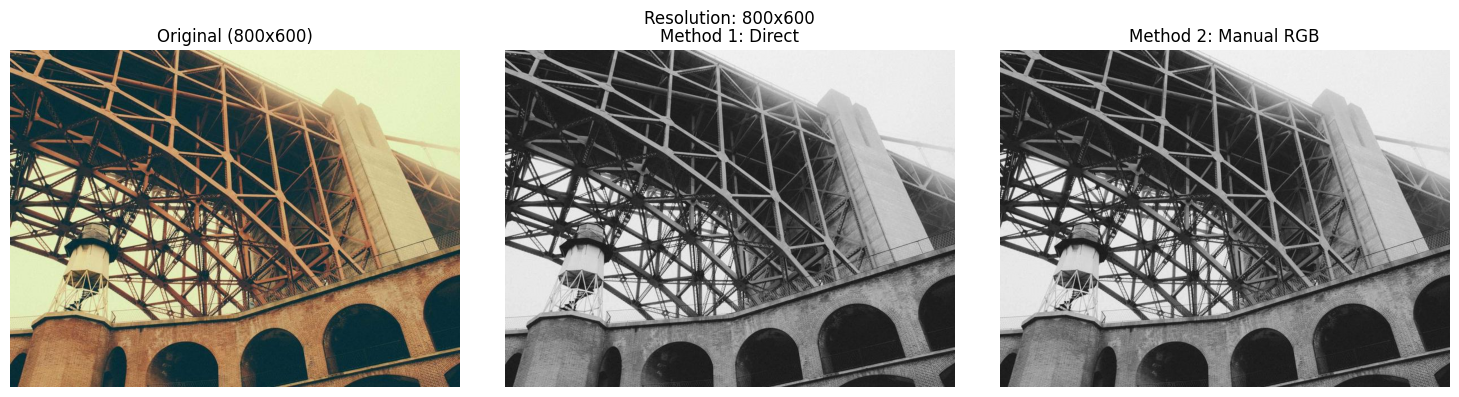


=== Resolution: 1920x1080 ===
Max pixel diff between methods : 1
Mean pixel diff                : 0.0126


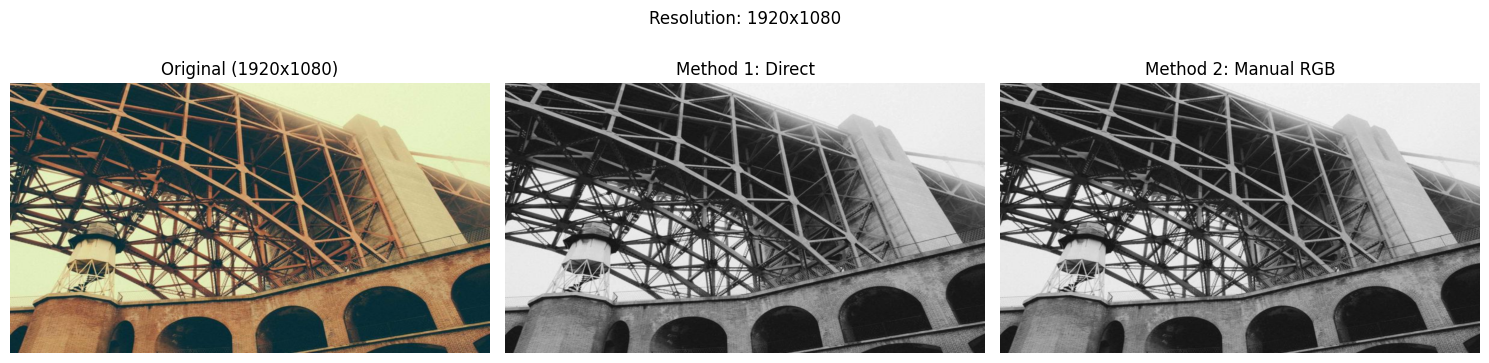

In [3]:
import cv2
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

# Use one image at two resolutions
src = cv2.imread("images/img_01.jpg")
resolutions = {
    "800x600": cv2.resize(src, (800, 600)),
    "1920x1080": cv2.resize(src, (1920, 1080))
}

for res_name, img in resolutions.items():
    print(f"\n=== Resolution: {res_name} ===")

    # Transfer to GPU
    img_gpu = cp.asarray(img)   # BGR

    # ── Method 1: Direct grayscale (OpenCV formula) ──────────
    # cv2.COLOR_BGR2GRAY: 0.114*B + 0.587*G + 0.299*R
    gray_direct = cp.clip(
        0.114*img_gpu[:,:,0] + 0.587*img_gpu[:,:,1] + 0.299*img_gpu[:,:,2],
        0, 255).astype(cp.uint8)

    # ── Method 2: Manual from RGB channels ───────────────────
    # Standard luminance: 0.2989*R + 0.5870*G + 0.1140*B
    # img is BGR so: R=ch2, G=ch1, B=ch0
    gray_manual = cp.clip(
        0.2989*img_gpu[:,:,2] + 0.5870*img_gpu[:,:,1] + 0.1140*img_gpu[:,:,0],
        0, 255).astype(cp.uint8)

    # Back to CPU for display
    g1 = cp.asnumpy(gray_direct)
    g2 = cp.asnumpy(gray_manual)

    diff = np.abs(g1.astype(np.int16) - g2.astype(np.int16))
    print(f"Max pixel diff between methods : {diff.max()}")
    print(f"Mean pixel diff                : {diff.mean():.4f}")

    # Display
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    axes[0].imshow(cv2.cvtColor(cp.asnumpy(img_gpu), cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"Original ({res_name})")
    axes[1].imshow(g1, cmap='gray'); axes[1].set_title("Method 1: Direct")
    axes[2].imshow(g2, cmap='gray'); axes[2].set_title("Method 2: Manual RGB")
    for ax in axes: ax.axis('off')
    plt.suptitle(f"Resolution: {res_name}")
    plt.tight_layout(); plt.show()

Why YCbCr in JPEG?
Human eyes are more sensitive to brightness (luminance) than color. YCbCr separates luminance (Y) from chrominance (Cb, Cr), allowing JPEG to compress color channels more aggressively without visible quality loss — this is called chroma subsampling.
Why convert to RGB only after IDCT?
JPEG compression works entirely in YCbCr space: DCT → quantization → Huffman coding. The IDCT reconstructs YCbCr coefficients. Converting to RGB before IDCT would mean operating on 3 mixed channels instead of 1 independent luminance + 2 downsampled chroma, wasting computation. RGB conversion is the very last step once pixel values are fully reconstructed.

Q3 — Pipeline A (Hybrid CPU→GPU) vs Pipeline B (DALI)

Pipeline A — Hybrid (OpenCV decode + CuPy GPU ops)

In [4]:
import cv2
import numpy as np
import cupy as cp
import cupyx.scipy.ndimage as cpnd
import time
import matplotlib.pyplot as plt

image_files = sorted([f"images/img_{i:02d}.jpg" for i in range(1, 21)])
TARGET = (224, 224)
BATCH_SIZES = [1, 4, 8, 20]

def pipeline_A_batch(paths, target=(224,224)):
    times = []
    for p in paths:
        t = time.perf_counter()
        img = cv2.imread(p)                         # CPU decode
        img_gpu = cp.asarray(img)                   # → GPU
        zy = target[0]/img_gpu.shape[0]
        zx = target[1]/img_gpu.shape[1]
        img_gpu = cpnd.zoom(img_gpu, (zy, zx, 1))  # GPU resize
        # GPU normalize to [0,1]
        img_gpu = img_gpu.astype(cp.float32) / 255.0
        cp.cuda.Stream.null.synchronize()
        times.append(time.perf_counter() - t)
    return sum(times)

print("Pipeline A (Hybrid) results:")
A_results = {}
for bs in BATCH_SIZES:
    batch = image_files[:bs]
    total = pipeline_A_batch(batch)
    throughput = bs / total
    A_results[bs] = {"time": total, "throughput": throughput}
    print(f"  Batch {bs:>2}: {total*1000:.2f} ms  |  {throughput:.2f} img/s")

Pipeline A (Hybrid) results:
  Batch  1: 490.96 ms  |  2.04 img/s
  Batch  4: 52.92 ms  |  75.59 img/s
  Batch  8: 124.78 ms  |  64.11 img/s
  Batch 20: 293.43 ms  |  68.16 img/s


Pipeline B — DALI

In [5]:
!pip install nvidia-dali-cuda120 -q   # match your CUDA version

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 MB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 86.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 87.5 MB/s eta 0:00:00


In [9]:
import nvidia.dali as dali
import nvidia.dali.fn as fn
import nvidia.dali.types as types
from nvidia.dali.pipeline import Pipeline
import time

image_files = sorted([f"images/img_{i:02d}.jpg" for i in range(1, 21)])
TARGET = (224, 224)
BATCH_SIZES = [1, 4, 8, 20]

def build_dali_pipeline(file_list, batch_size):
    pipe = Pipeline(batch_size=batch_size, num_threads=2, device_id=0)
    with pipe:
        jpegs, _ = fn.readers.file(files=file_list, random_shuffle=False)
        images = fn.decoders.image(jpegs, device="mixed")
        images = fn.resize(images, device="gpu",
                           resize_x=TARGET[1], resize_y=TARGET[0])
        images = fn.crop_mirror_normalize(
            images, device="gpu",
            mean=[0.0, 0.0, 0.0],
            std=[255.0, 255.0, 255.0],
            output_layout="HWC")
        pipe.set_outputs(images)
    return pipe

print("Pipeline B (DALI) results:")
B_results = {}
for bs in BATCH_SIZES:
    batch_files = image_files[:bs]
    pipe = build_dali_pipeline(batch_files, batch_size=bs)
    pipe.build()
    pipe.run()  # warmup
    t = time.perf_counter()
    pipe.run()
    elapsed = time.perf_counter() - t
    throughput = bs / elapsed
    B_results[bs] = {"time": elapsed, "throughput": throughput}
    print(f"  Batch {bs:>2}: {elapsed*1000:.2f} ms  |  {throughput:.2f} img/s")

Pipeline B (DALI) results:
  Batch  1: 0.17 ms  |  5776.97 img/s
  Batch  4: 13.30 ms  |  300.84 img/s
  Batch  8: 18.74 ms  |  426.92 img/s
  Batch 20: 43.53 ms  |  459.48 img/s


Comparison Table + Graph


── Comparison Table ────────────────────────────────────
+---------+--------------+-----------+--------------+-----------+---------------+
|   Batch |   A Time(ms) |   A img/s |   B Time(ms) |   B img/s | Speedup B/A   |
+=========+==============+===========+==============+===========+===============+
|       1 |       490.96 |      2.04 |         0.17 |   5776.97 | 5776974.14x   |
+---------+--------------+-----------+--------------+-----------+---------------+
|       4 |        52.92 |     75.59 |        13.3  |    300.84 | 75208.98x     |
+---------+--------------+-----------+--------------+-----------+---------------+
|       8 |       124.78 |     64.11 |        18.74 |    426.92 | 53365.06x     |
+---------+--------------+-----------+--------------+-----------+---------------+
|      20 |       293.43 |     68.16 |        43.53 |    459.48 | 22973.79x     |
+---------+--------------+-----------+--------------+-----------+---------------+


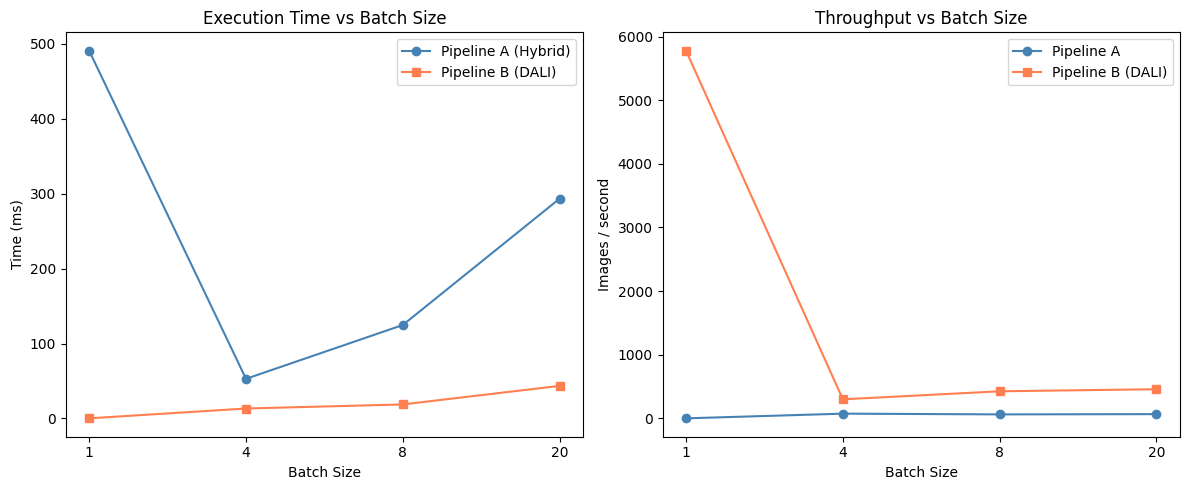

In [10]:
from tabulate import tabulate

print("\n── Comparison Table ────────────────────────────────────")
rows = []
for bs in BATCH_SIZES:
    at = A_results[bs]["time"]*1000
    bt = B_results[bs]["time"]*1000
    at_tp = A_results[bs]["throughput"]
    bt_tp = B_results[bs]["throughput"]
    rows.append([bs, f"{at:.2f}", f"{at_tp:.2f}",
                     f"{bt:.2f}", f"{bt_tp:.2f}",
                     f"{at/B_results[bs]['time']/A_results[bs]['time']:.2f}x"
                     if B_results[bs]['time'] > 0 else "-"])

print(tabulate(rows,
    headers=["Batch", "A Time(ms)", "A img/s", "B Time(ms)", "B img/s", "Speedup B/A"],
    tablefmt="grid"))

# Graph
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
bs_labels = [str(b) for b in BATCH_SIZES]

ax1.plot(bs_labels, [A_results[b]["time"]*1000 for b in BATCH_SIZES],
         marker='o', label='Pipeline A (Hybrid)', color='steelblue')
ax1.plot(bs_labels, [B_results[b]["time"]*1000 for b in BATCH_SIZES],
         marker='s', label='Pipeline B (DALI)', color='coral')
ax1.set_xlabel("Batch Size"); ax1.set_ylabel("Time (ms)")
ax1.set_title("Execution Time vs Batch Size"); ax1.legend()

ax2.plot(bs_labels, [A_results[b]["throughput"] for b in BATCH_SIZES],
         marker='o', label='Pipeline A', color='steelblue')
ax2.plot(bs_labels, [B_results[b]["throughput"] for b in BATCH_SIZES],
         marker='s', label='Pipeline B (DALI)', color='coral')
ax2.set_xlabel("Batch Size"); ax2.set_ylabel("Images / second")
ax2.set_title("Throughput vs Batch Size"); ax2.legend()

plt.tight_layout()
plt.savefig("q3_comparison.png", dpi=150)
plt.show()